# 评测方法论

> 模型训完之后，判断它是否真的比上一版更强，需要的是客观、可复现的分数，而不是「感觉变好了」这样的主观印象。评测就是把「模型好不好」这个主观问题转化为可量化、可复现的客观分数的过程。
>
> 这一节理解论文和工业界真正在用的评测体系：评测指标怎么定义、开源评测框架怎么用、LLM-as-Judge 怎么让强模型当裁判打分，以及如何看懂结果并写出有说服力的对比报告。

核心三要素是标准化考题（benchmark）、自动化批改（metric）和可复现的流程（evaluation pipeline）。LLM-as-Judge 是近年兴起的做法：用 GPT-4 这类强模型来评判其他模型的回答质量。在 MT-Bench、Chatbot Arena 这类设置中，强模型 judge 与人类偏好有较高一致性；但一致性依赖任务、judge prompt、模型版本和答案格式。参考：[MT-Bench / Chatbot Arena](https://arxiv.org/abs/2306.05685)。

LLM-as-Judge 也有自己的陷阱——位置偏见、长度偏见和格式偏见都可能导致评分失真。

Perplexity 衡量模型在给定文本上预测下一个 token 的平均不确定性。它适合语言建模和预训练监控，但不能直接代表聊天质量、推理能力或安全性。

In [1]:
import sys

print(f"Python: {sys.version.split()[0]}")

# 检查本节会用到的关键依赖
deps = ["openai", "datasets", "lm_eval"]
for pkg in deps:
    try:
        __import__(pkg)
        print(f"  {pkg}: 已安装")
    except ImportError:
        print(f"  {pkg}: 未安装 (pip install {pkg})")


Python: 3.13.13


  openai: 已安装


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  datasets: 已安装
  lm_eval: 未安装 (pip install lm_eval)


## 1. 评测全景

### 1.1 评测演进路线（教学版时间线）

```
2019-2021         2022-2023            2024-2025
  ↓                  ↓                     ↓
GLUE/SuperGLUE   MMLU/GSM8K         LLM-as-Judge
BERT 时代        GPT-4 时代           Agent 时代
选择题为主       选择题 + 生成题      多轮 + 工具 + 安全
```

### 1.2 近年论文和工业界常见评测维度

| 维度 | 代表数据集 | 指标 | 为什么重要 |
|:---|:---|:---|:---|
| **知识** | MMLU-Pro、GPQA | acc | 常见于头部模型报告 |
| **数学推理** | GSM8K、MATH、AIME 2024 | exact_match | 推理能力的硬指标 |
| **代码** | HumanEval+、LiveCodeBench、SWE-bench | pass@k | 程序员最关心的 |
| **指令遵循** | IFEval、MT-Bench | strict_acc | 决定实际可用性 |
| **对话质量** | AlpacaEval、Chatbot Arena | win_rate/Elo | 强模型当裁判 |
| **安全** | TruthfulQA、Garak | 违规率 | 上线前通常需要覆盖 |
| **长文本** | Needle-in-Haystack、RULER | recall | RAG 场景关键 |
| **多语言** | CMMLU、C-Eval | acc | 不能只评英文 |
| **Agent** | SWE-bench、WebArena | success_rate | 近年快速发展的方向 |

### 1.3 通用模型常见评测组合

通用模型技术报告通常会覆盖这些维度，但具体集合取决于模型定位。代码模型、RAG 系统、医疗/法律模型不应该只照搬通用榜单：

```
基础：MMLU-Pro + GPQA + HellaSwag
代码：HumanEval+ + LiveCodeBench + SWE-bench（Agent 场景）
数学：GSM8K + MATH + AIME 2024
对话：AlpacaEval 2.0 / Chatbot Arena Elo
指令：IFEval + MT-Bench
安全：TruthfulQA + 红队测试
```

**新手最小评测集**（先跑通这 4 个再扩展）：GSM8K → MMLU → HumanEval → IFEval

## 2. 核心评测框架 & Repo 推荐

下面是工业界和学术界常用的几个评测框架。这里按教学实用性组织，不代表唯一排序：

### 2.1 lm-evaluation-harness（EleutherAI）— 开源评测常用框架

```bash
git clone https://github.com/EleutherAI/lm-evaluation-harness.git
cd lm-evaluation-harness
pip install -e .
```

- **地位**：开源模型评测中非常常用的框架之一，很多 leaderboard 和论文会使用它或兼容的任务/指标。跨论文对比时仍要核对 prompt、few-shot、解析和模型版本。参考：[lm-evaluation-harness](https://github.com/EleutherAI/lm-evaluation-harness)
- **能力**：200+ 数据集，一行命令搞定 API 评测 / HF 评测 / vLLM 评测
- **OpenAI-Compatible 支持**：`local-completions` 和 `local-chat-completions` 两个模型类型，连接任何兼容 API

### 2.2 AlpacaEval — 常用 LLM-as-Judge 工具

```bash
git clone https://github.com/tatsu-lab/alpaca_eval.git
cd alpaca_eval
pip install -e .
```

- **地位**：常用的自动对话评测工具之一，特别强调 length-controlled win rate；不能替代人工评审和业务评测。参考：[AlpacaEval](https://github.com/tatsu-lab/alpaca_eval)、[LC AlpacaEval](https://arxiv.org/abs/2404.04475)
- **核心指标**：LC Win Rate（Length-Controlled，控制长度偏差）、WR（原始胜率）
- **800+ 条 prompt**，对比你的模型和 GPT-4/Davinci-003 的回答，用 GPT-4 判胜负

### 2.3 FastChat（LMSYS）— Chatbot Arena 同款

```bash
git clone https://github.com/lm-sys/FastChat.git
cd FastChat
pip install -e ".[eval]"
```

- **地位**：Chatbot Arena 是影响力很大的众包对战评测平台之一；FastChat 提供 MT-Bench 和相关 judge 工具
- **核心能力**：MT-Bench（80 道多轮问题 + GPT-4 打分）、Chatbot Arena（1M+ 人类投票）

### 2.4 DeepEval — CI/CD 友好

```bash
pip install deepeval
```

- **地位**：pytest 风格，可集成到 CI/CD 管线
- **特色**：幻觉检测、答案相关性、忠实度、G-Eval（用思维链评测）

### 框架选型速查

| 场景 | 推荐框架 |
|:---|:---|
| **论文报分 / 开源模型评测** | lm-evaluation-harness |
| **对话质量评估** | AlpacaEval / FastChat MT-Bench |
| **CI/CD 持续评测** | DeepEval / Promptfoo |
| **安全测试** | Garak（NVIDIA） |
| **Agent 评测** | SWE-bench + WebArena |

**本 Part 重点**：用 lm-evaluation-harness 做核心评测，用 AlpacaEval 做对话质量评测。

## 3. OpenAI-Compatible API 评测实战

这是最实用的评测方式——你部署了一个兼容 OpenAI API 的服务（vLLM、Ollama、DeepSeek、各种网关），直接调 API 跑评测。

### 3.1 核心原理

lm-evaluation-harness 通过两个模型类型支持 OpenAI-Compatible API：

| 模型类型 | API 端点 | 支持任务 |
|:---|:---|:---|
| `local-chat-completions` | `/v1/chat/completions` | 生成题（GSM8K、HumanEval、IFEval） |
| `local-completions` | `/v1/completions` | 生成题 + 选择题（MMLU 需要 logprobs） |

**关键区别**：经典 MMLU / HellaSwag 这类选择题通常需要每个选项的 token logprob。很多 Chat Completions API 不暴露足够的 logprobs，因此常用 completions/logits 路线；也可以改写成生成式选择题，但分数不能和默认 leaderboard 直接比较。

### 3.2 支持的服务

任何兼容 OpenAI API 的服务都可以：

```
OpenAI API          → 需要 API Key
DeepSeek API        → 兼容 OpenAI 格式
vLLM 部署           → http://localhost:8000/v1
Ollama              → http://localhost:11434/v1
LiteLLM 代理         → 统一代理多个后端
SGLang              → http://localhost:30000/v1
```

**一句话**：如果服务能接收 `POST /v1/chat/completions`，通常可以跑生成类任务；但选择题/loglikelihood 类任务还需要 completions/logprobs 或本地 logits。不同 OpenAI-compatible 服务对 logprobs、chat template、stop、reasoning_content 的支持并不完全相同。

GSM8K 是生成题，用 Chat Completions API 即可评测。下面是命令模板，把 `base_url`、`model` 和 `token` 换成你的实际配置：

```bash
# 闭源 API（OpenAI）
lm_eval --model local-chat-completions \
    --model_args model=gpt-4o-mini,base_url=https://api.openai.com/v1/chat/completions,token=$OPENAI_API_KEY,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks gsm8k --batch_size 8 \
    --output_path ./eval_results/gsm8k_openai

# 闭源 API（DeepSeek，与 OpenAI 格式兼容）
lm_eval --model local-chat-completions \
    --model_args model=deepseek-chat,base_url=https://api.deepseek.com/v1/chat/completions,token=$DEEPSEEK_API_KEY,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks gsm8k --batch_size 8 \
    --output_path ./eval_results/gsm8k_deepseek

# 本地部署（vLLM）
lm_eval --model local-chat-completions \
    --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks gsm8k --batch_size 8 \
    --output_path ./eval_results/gsm8k_vllm

# 本地部署（Ollama）
lm_eval --model local-chat-completions \
    --model_args model=llama3,base_url=http://localhost:11434/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks gsm8k --batch_size 8 \
    --output_path ./eval_results/gsm8k_ollama
```

前提是 `pip install lm-eval` 已经完成。

MMLU 是选择题，默认通过 loglikelihood 评测（计算每个选项的概率），需要 Completions API 暴露 logprobs。Chat Completions API 在 loglikelihood 任务上会报 `NotImplementedError`。

```bash
# vLLM 的 /v1/completions 端点返回 logprobs，可以跑经典 MMLU
lm_eval --model local-completions \
    --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/completions,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks mmlu --batch_size 16 \
    --output_path ./eval_results/mmlu
```

注意点：

- OpenAI 的 `gpt-4o-mini` 不支持 `/v1/completions`，需要用 `davinci-002` 等老模型
- DeepSeek 的 `/v1/completions` 也可能不支持，跑生成题用 Chat API 即可
- 如果只能拿到 Chat API，可以把 MMLU 改写成生成式版本（让模型输出 A/B/C/D），但分数和默认 leaderboard 不可直接对比

实战建议：用 vLLM 部署一个开源模型，跑 MMLU 时用 `local-completions`，跑 GSM8K 时用 `local-chat-completions`，这是最完整的工作流。

### 3.3 批量评测多个数据集（Python API）

CLI 方式适合单次快速验证，但在 notebook 中做系统性的多数据集评测时，Python API 更灵活。可以写循环遍历多个 benchmark，自定义每个数据集的 few-shot 数量和采样策略，把结果收集到一个统一的 DataFrame 中做后续分析。

lm-eval 的 Python API 提供了 `simple_evaluate` 函数，参数和 CLI 基本一致，但返回的是 Python 字典，方便直接在代码中处理和可视化。下面用它批量跑三个常用 benchmark。

In [2]:
# lm_eval Python API 批量评测示例
# CLI 适合单次跑，Python API 适合在 Notebook 里做系统性多任务评测

import os

try:
    from lm_eval import simple_evaluate
    HAS_LMEVAL = True
except ImportError:
    HAS_LMEVAL = False
    print("lm_eval 未安装，下面展示 simple_evaluate 的典型用法和结果格式")
    print("安装后即可真实运行：pip install lm-eval\n")

HAS_DEEPSEEK_KEY = bool(os.environ.get("DEEPSEEK_API_KEY"))

if HAS_LMEVAL and HAS_DEEPSEEK_KEY:
    # 真实运行示例（需要 API Key 或本地模型）
    results = simple_evaluate(
        model="local-chat-completions",
        model_args="model=deepseek-chat,base_url=https://api.deepseek.com/v1/chat/completions,token=$DEEPSEEK_API_KEY,num_concurrent=4",
        tasks=["gsm8k", "ifeval"],
        batch_size=8,
    )
    for task, metrics in results["results"].items():
        print(f"{task}: {metrics}")
else:
    if HAS_LMEVAL and not HAS_DEEPSEEK_KEY:
        print("lm_eval 已安装，但没有 DEEPSEEK_API_KEY；本次展示结果格式，不调用外部 API。")
    # 示例输出格式（参考公开技术报告的典型量级，仅用于演示结构）
    example_results = {
        "gsm8k": {"exact_match,strict-match": 0.834, "exact_match,flexible-extract": 0.871},
        "mmlu": {"acc,none": 0.743, "acc_norm,none": 0.725},
        "hellaswag": {"acc,none": 0.829, "acc_norm,none": 0.841},
        "ifeval": {"prompt_level_strict_acc,none": 0.687, "inst_level_strict_acc,none": 0.763},
        "humaneval": {"pass@1": 0.689},
    }
    for task, metrics in example_results.items():
        print(f"{task}:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.4f}")


lm_eval 未安装，下面展示 simple_evaluate 的典型用法和结果格式
安装后即可真实运行：pip install lm-eval

gsm8k:
  exact_match,strict-match: 0.8340
  exact_match,flexible-extract: 0.8710
mmlu:
  acc,none: 0.7430
  acc_norm,none: 0.7250
hellaswag:
  acc,none: 0.8290
  acc_norm,none: 0.8410
ifeval:
  prompt_level_strict_acc,none: 0.6870
  inst_level_strict_acc,none: 0.7630
humaneval:
  pass@1: 0.6890


## 4. LLM-as-Judge：用 强模型当裁判

选择题和数学题有标准答案，但「对话质量好不好」没有——这就是 **LLM-as-Judge** 的用武之地。

### 4.1 核心思想

```
你的模型回答  ──→  GPT-4 打分  ──→  对比 baseline 回答  ──→  胜率 (Win Rate)
baseline 回答  ──→              ──→                       ──→
```

两个主流框架：
- **AlpacaEval 2.0**：805 条 prompt，你的模型 vs GPT-4，用 GPT-4 Turbo 当裁判
- **MT-Bench**：80 条多轮对话问题，GPT-4 分维度打分（1-10 分）

### 4.2 关键概念

| 指标 | 含义 | 怎么看 |
|:---|:---|:---|
| **Win Rate (WR)** | 你的回答被判定优于 baseline 的比例 | GPT-4 作为 baseline ≈ 50% |
| **LC Win Rate** | Length-Controlled WR，控制回答长度偏差 | 比 WR 更公平，避免「话多就赢」 |
| **MT-Bench Score** | GPT-4 对回答的 1-10 评分均值 | 7+ 算好，8+ 很强 |
| **Elo Rating** | 类似国际象棋的 Elo 分，从对战记录推算 | Chatbot Arena 标准输出 |

### 4.3 实战：用 OpenAI SDK 实现 LLM-as-Judge

下面直接写一个完整可用的 judge — 不需要额外框架。

In [3]:
# 直接用 OpenAI SDK 实现 LLM-as-Judge
# 核心：把问题、模型回答、参考回答组装进 prompt，让 GPT-4 打分

JUDGE_PROMPT = """Please act as an impartial judge and evaluate the quality of the response provided by an AI assistant to the user question displayed below.

Your evaluation should consider the following factors:
1. Helpfulness: Does the response address the user's needs?
2. Accuracy: Is the information factually correct?
3. Relevance: Does the response stay on topic?
4. Depth: Does it provide meaningful detail?
5. Creativity: Is the response well-structured and clear?

Begin your evaluation by providing a short explanation. Be as objective as possible.
After providing your explanation, you must rate the response on a scale of 1 to 10 by strictly following this format:
"[[rating]]", for example: "Rating: [[7]]".

[Question]
{question}

[The Start of Assistant's Answer]
{answer}
[The End of Assistant's Answer]"""


# 评测样本（MT-Bench 风格题目）
eval_samples = [
    {
        "question": "Write a Python function to find the longest common subsequence of two strings.",
        "good_answer": "Here's a Python implementation of LCS using dynamic programming:\n\n```python\ndef lcs(s1: str, s2: str) -> str:\n    m, n = len(s1), len(s2)\n    dp = [[\"\"] * (n + 1) for _ in range(m + 1)]\n    for i in range(1, m + 1):\n        for j in range(1, n + 1):\n            if s1[i-1] == s2[j-1]:\n                dp[i][j] = dp[i-1][j-1] + s1[i-1]\n            else:\n                dp[i][j] = max(dp[i-1][j], dp[i][j-1], key=len)\n    return dp[m][n]\n```\n\nTime complexity: O(mn), Space: O(mn).",
        "bad_answer": "def lcs(s1, s2):\n    return ''.join(c for c in s1 if c in s2)",
    },
    {
        "question": "Explain the concept of quantum entanglement in simple terms.",
        "good_answer": "Quantum entanglement is when two particles become linked in such a way that the state of one instantly influences the state of the other, no matter how far apart they are. Imagine two magic coins: when you flip them, if one shows heads, the other always shows tails — even if they're on opposite sides of the universe. Einstein called this 'spooky action at a distance' because it seems to violate the idea that nothing can travel faster than light. Today, entanglement is a proven phenomenon and forms the basis for quantum computing and quantum cryptography.",
        "bad_answer": "Quantum entanglement is when two things are connected. It's like twins who can feel each other's pain. Scientists use it for computers.",
    },
]


def judge_with_gpt(question, answer):
    """用 GPT-4 打分（需要 OPENAI_API_KEY 环境变量）"""
    try:
        from openai import OpenAI
        client = OpenAI()  # 自动读取 OPENAI_API_KEY
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{
                "role": "user",
                "content": JUDGE_PROMPT.format(question=question, answer=answer)
            }],
            temperature=0,
            max_tokens=512,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"[Judge unavailable: {e}]"


import re
for i, sample in enumerate(eval_samples):
    print(f"题目 {i+1}: {sample['question']}")
    print(f"{'-'*60}")
    for label, answer in [("Good Answer", sample['good_answer']), ("Bad Answer", sample['bad_answer'])]:
        verdict = judge_with_gpt(sample['question'], answer)
        match = re.search(r'\[\[(\d+(?:\.\d+)?)\]\]', verdict)
        if match:
            print(f"  {label}: {match.group(1)}/10")
        else:
            preview = verdict[:150].replace('\n', ' ')
            print(f"  {label}: {preview}...")
    print()

print("规模化后：N 条 prompt × M 个模型 × GPT-4 裁判 = 完整的 LLM-as-Judge 评测")
print("这就是 MT-Bench 和 AlpacaEval 的核心原理。")


题目 1: Write a Python function to find the longest common subsequence of two strings.
------------------------------------------------------------
  Good Answer: [Judge unavailable: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_...
  Bad Answer: [Judge unavailable: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_...

题目 2: Explain the concept of quantum entanglement in simple terms.
------------------------------------------------------------
  Good Answer: [Judge unavailable: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_...
  Bad Answer: [Judge unavailable: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_...

规模化后：N 条 prompt × M 个模型 × GPT-4 裁判 = 完整的 LLM-as-Ju

## 5. 评测结果的汇总与对比


In [4]:
# 评测结果汇总与可视化
# 示例数据：用于演示汇总和可视化的格式；真实报告必须逐项标注来源、模型版本和评测配置
benchmark_results = {
    "GPT-4o": {
        "MMLU": 88.7, "GSM8K": 96.1, "HumanEval": 90.2, "HellaSwag": 95.3,
        "IFEval": 84.3, "GPQA": 53.6, "AlpacaEval LC": 57.5,
    },
    "DeepSeek-V3 (671B)": {
        "MMLU": 88.5, "GSM8K": 95.3, "HumanEval": 82.6, "HellaSwag": 89.0,
        "IFEval": 86.1, "GPQA": 59.1, "AlpacaEval LC": 54.2,
    },
    "Qwen2.5-72B": {
        "MMLU": 86.1, "GSM8K": 91.6, "HumanEval": 86.6, "HellaSwag": 86.9,
        "IFEval": 81.7, "GPQA": 49.0, "AlpacaEval LC": 50.5,
    },
    "Llama-3.1-70B": {
        "MMLU": 86.0, "GSM8K": 91.2, "HumanEval": 80.5, "HellaSwag": 85.0,
        "IFEval": 80.4, "GPQA": 46.7, "AlpacaEval LC": 44.8,
    },
    "Qwen2.5-7B (reference)": {
        "MMLU": 74.3, "GSM8K": 83.4, "HumanEval": 68.9, "HellaSwag": 82.1,
        "IFEval": 68.7, "GPQA": 36.7, "AlpacaEval LC": 38.5,
    },
}

datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA", "AlpacaEval LC"]

# 打印对比表
print("模型评测对比表（示例数据，用于演示格式）\n")

header = f"{'模型':<22s}"
for ds in datasets:
    header += f" {ds:>13s}"
print(header)
print("-" * (22 + 14 * len(datasets)))

for model, scores in benchmark_results.items():
    row = f"{model:<22s}"
    for ds in datasets:
        score = scores.get(ds)
        if score is None:
            row += f" {'N/A':>13s}"
        else:
            row += f" {score:>13.1f}"
    print(row)

# 关键分析
print("\n分析要点\n")
print("1. 同规模对比（7B vs 7B），不要跨量级对比（7B vs 671B）")
print("2. 关注和业务最相关的指标：做 API 的看 IFEval，做教育的看 MMLU")
print("3. 综合多个数据集看趋势，不要只盯一个数")
print("4. 标注数据来源和评测配置（prompt/few-shot/seed），保证可复现")
print("5. 模型大小不是唯一因素；不同模型在某些任务上强、某些任务上弱，结论必须绑定具体 benchmark 和评测配置")


模型评测对比表（示例数据，用于演示格式）

模型                              MMLU         GSM8K     HumanEval     HellaSwag        IFEval          GPQA AlpacaEval LC
------------------------------------------------------------------------------------------------------------------------
GPT-4o                          88.7          96.1          90.2          95.3          84.3          53.6          57.5
DeepSeek-V3 (671B)              88.5          95.3          82.6          89.0          86.1          59.1          54.2
Qwen2.5-72B                     86.1          91.6          86.6          86.9          81.7          49.0          50.5
Llama-3.1-70B                   86.0          91.2          80.5          85.0          80.4          46.7          44.8
Qwen2.5-7B (reference)          74.3          83.4          68.9          82.1          68.7          36.7          38.5

分析要点

1. 同规模对比（7B vs 7B），不要跨量级对比（7B vs 671B）
2. 关注和业务最相关的指标：做 API 的看 IFEval，做教育的看 MMLU
3. 综合多个数据集看趋势，不要只盯一个数
4. 标注数据来源和评测配置（prompt

### 5.1 可视化评测结果

光看数字表格不够直观。论文和 leaderboard 常用的两种图：

| 图类型 | 适用场景 | 例子 |
|:---|:---|:---|
| **雷达图（Radar/Spider）** | 多维度对比 2-4 个模型 | OpenAI/DeepSeek 技术报告标配 |
| **分组柱状图** | 逐项对比多个模型在多个数据集上的分数 | 论文 ablation 常用 |
| **胜率矩阵** | LLM-as-Judge 的两两对比结果 | Chatbot Arena 风格 |

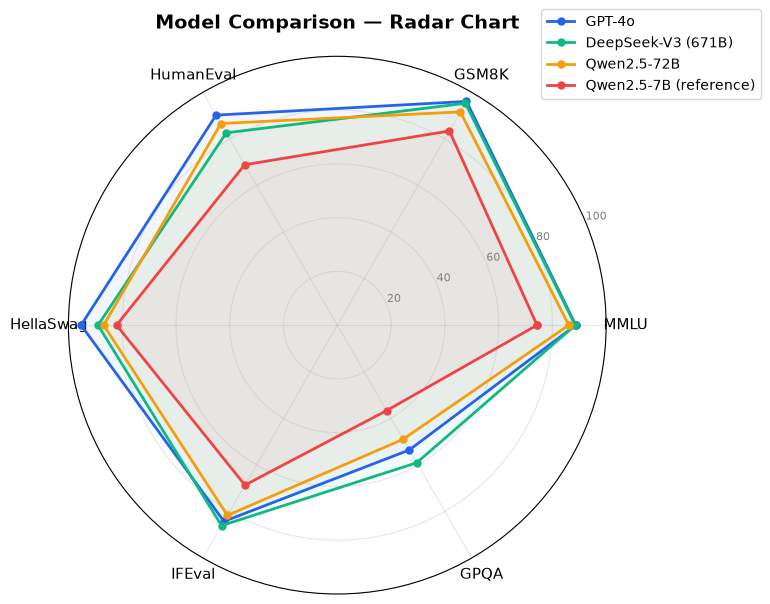

雷达图解读：面积越大越强，形状反映能力分布
这是基于上面示例数据的读图方式，不代表实时模型排名



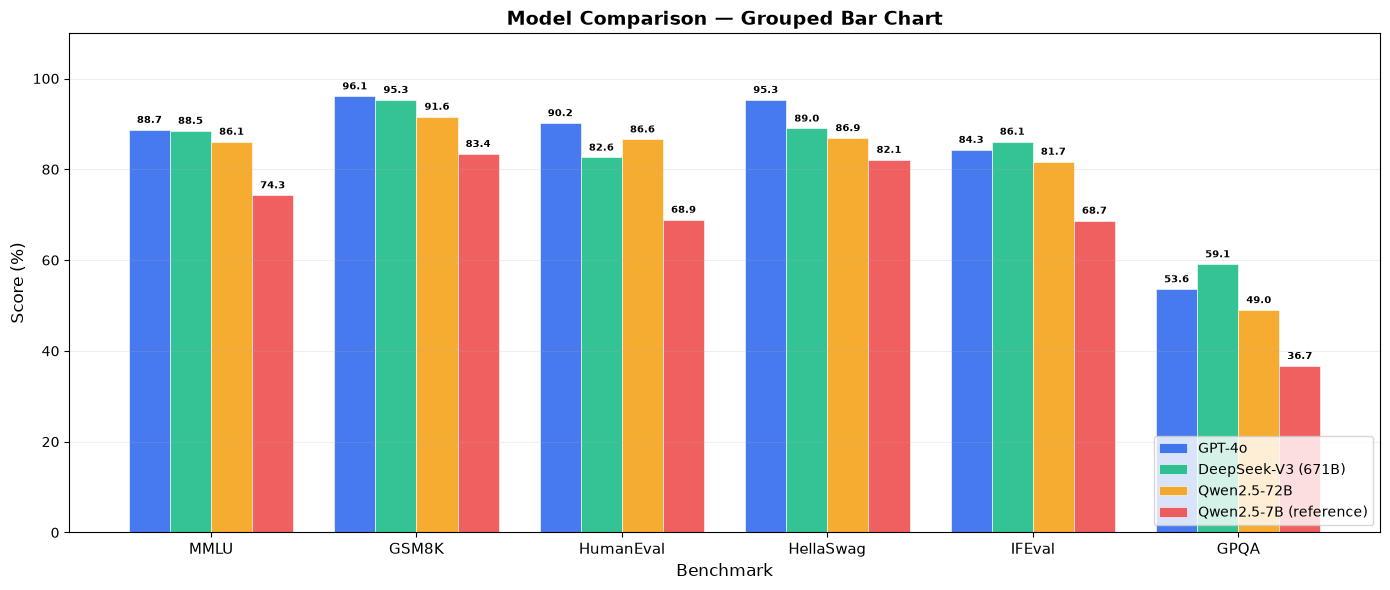

柱状图解读：逐项对比一目了然，适合论文 ablation 和汇报
参考模型（红色）在每个 benchmark 上和头部模型的差距就是提升空间

--- LLM-as-Judge 胜率矩阵示例 ---



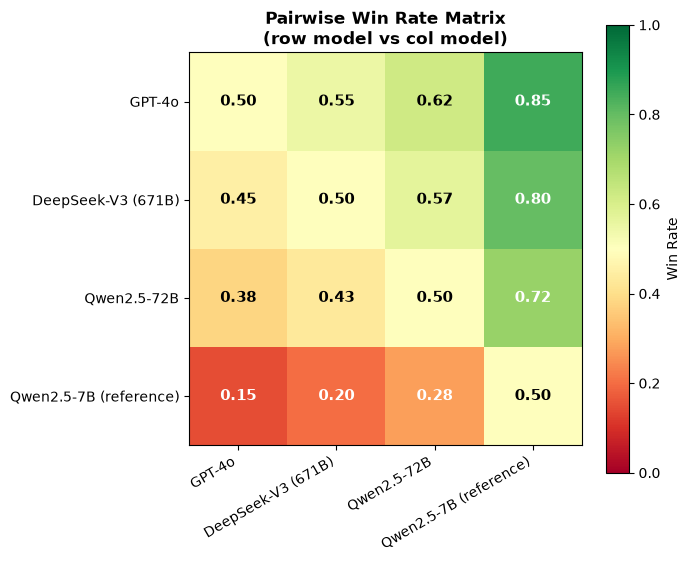

胜率矩阵：行模型 vs 列模型，>0.5 表示行模型更强
Qwen2.5-7B 在所有对比中都 < 0.5，说明与头部模型仍有明显差距


In [5]:
# 雷达图 + 柱状图 + 胜率矩阵：论文标配的三种可视化
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

# ============================================
# 图 1: 雷达图（Spider/Radar Chart）
# ============================================
radar_models = ["GPT-4o", "DeepSeek-V3 (671B)", "Qwen2.5-72B", "Qwen2.5-7B (reference)"]
radar_datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA"]
radar_colors = ["#2563EB", "#10B981", "#F59E0B", "#EF4444"]

radar_values = []
for model in radar_models:
    vals = [benchmark_results[model][ds] for ds in radar_datasets]
    radar_values.append(vals)

num_vars = len(radar_datasets)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 闭合

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model, values, color in zip(radar_models, radar_values, radar_colors):
    values_closed = values + values[:1]
    ax.fill(angles, values_closed, alpha=0.05, color=color)
    ax.plot(angles, values_closed, "o-", linewidth=2, color=color, label=model, markersize=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_datasets, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=8, color="gray")
ax.set_title("Model Comparison — Radar Chart", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("雷达图解读：面积越大越强，形状反映能力分布")
print("这是基于上面示例数据的读图方式，不代表实时模型排名\n")

# ============================================
# 图 2: 分组柱状图（Grouped Bar Chart）
# ============================================
bar_models = radar_models
bar_datasets = radar_datasets

x = np.arange(len(bar_datasets))
width = 0.2
n_models = len(bar_models)

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(bar_models, radar_colors)):
    values = [benchmark_results[model][ds] for ds in bar_datasets]
    offset = width * (i - n_models/2 + 0.5)
    bars = ax.bar(x + offset, values, width, label=model, color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f"{val:.1f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xlabel("Benchmark", fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Model Comparison — Grouped Bar Chart", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(bar_datasets, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("柱状图解读：逐项对比一目了然，适合论文 ablation 和汇报")
print("参考模型（红色）在每个 benchmark 上和头部模型的差距就是提升空间\n")

# ============================================
# 图 3: 胜率矩阵（LLM-as-Judge 风格）
# ============================================
print("--- LLM-as-Judge 胜率矩阵示例 ---\n")

models_for_matrix = ["GPT-4o", "DeepSeek-V3 (671B)", "Qwen2.5-72B", "Qwen2.5-7B (reference)"]
n_mat = len(models_for_matrix)
# 示例胜率矩阵：行模型 vs 列模型的胜率
win_rate_matrix = np.array([
    [0.50, 0.55, 0.62, 0.85],
    [0.45, 0.50, 0.57, 0.80],
    [0.38, 0.43, 0.50, 0.72],
    [0.15, 0.20, 0.28, 0.50],
])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(win_rate_matrix, cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(n_mat))
ax.set_yticks(range(n_mat))
ax.set_xticklabels(models_for_matrix, fontsize=10, rotation=30, ha="right")
ax.set_yticklabels(models_for_matrix, fontsize=10)
ax.set_title("Pairwise Win Rate Matrix\n(row model vs col model)", fontsize=12, fontweight="bold")

for i in range(n_mat):
    for j in range(n_mat):
        color = "white" if win_rate_matrix[i][j] < 0.3 or win_rate_matrix[i][j] > 0.7 else "black"
        ax.text(j, i, f"{win_rate_matrix[i][j]:.2f}", ha="center", va="center", fontsize=11, fontweight="bold", color=color)

plt.colorbar(im, ax=ax, label="Win Rate")
plt.tight_layout()
plt.show()

print("胜率矩阵：行模型 vs 列模型，>0.5 表示行模型更强")
print("Qwen2.5-7B 在所有对比中都 < 0.5，说明与头部模型仍有明显差距")


In [6]:
# 综合评分计算：多种聚合方法对比
import numpy as np
from scipy import stats

print("=== 综合评分计算 ===\n")

# 用前面已有的 benchmark_results
scores = benchmark_results

# 选取用于计算的 benchmark（排除 AlpacaEval LC 因为最高分不是 100-based）
eval_datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA"]

print("### 方法对比\n")

# --- 1. 简单平均 ---
print("1. 简单平均 (Arithmetic Mean)")
print(f"{'模型':<22s} {'Avg':>6s} {'Std':>6s}")
print("-" * 36)
for model in scores:
    vals = [scores[model][ds] for ds in eval_datasets]
    avg = np.mean(vals)
    std = np.std(vals)
    print(f"{model:<22s} {avg:>6.1f} {std:>6.1f}")

# --- 2. 几何平均 ---
print(f"\n2. 几何平均 (Geometric Mean) — 惩罚短板")
print(f"{'模型':<22s} {'GMean':>6s}")
print("-" * 30)
for model in scores:
    vals = [scores[model][ds] for ds in eval_datasets]
    gmean = stats.gmean(vals)
    print(f"{model:<22s} {gmean:>6.1f}")

# --- 3. 加权平均 ---
print(f"\n3. 加权平均 (Weighted) — 假设知识+代码权重更高")
weights = {"MMLU": 0.25, "GSM8K": 0.20, "HumanEval": 0.20, "HellaSwag": 0.10, "IFEval": 0.15, "GPQA": 0.10}
print(f"   权重: {weights}")
print(f"{'模型':<22s} {'Weighted':>8s}")
print("-" * 32)
for model in scores:
    weighted = sum(scores[model][ds] * weights[ds] for ds in eval_datasets)
    print(f"{model:<22s} {weighted:>8.1f}")

# --- 4. 归一化到最强模型 ---
print(f"\n4. 归一化平均 (Normalized) — 以 GPT-4o 为 100% 基准")
baseline = "GPT-4o"
print(f"{'模型':<22s}", end="")
for ds in eval_datasets:
    print(f" {ds:>8s}", end="")
print(f" {'Avg%':>8s}")
print("-" * (22 + 10 * len(eval_datasets) + 8))
for model in scores:
    normalized = [scores[model][ds] / scores[baseline][ds] * 100 for ds in eval_datasets]
    avg_norm = np.mean(normalized)
    print(f"{model:<22s}", end="")
    for nv in normalized:
        print(f" {nv:>8.1f}", end="")
    print(f" {avg_norm:>8.1f}")

# --- 5. 排名求和 ---
print(f"\n5. 排名求和 (Rank Sum) — 越小越好")
models_list = list(scores.keys())
ranks = {ds: np.argsort([-scores[m][ds] for m in models_list]).argsort() + 1 for ds in eval_datasets}
print(f"{'模型':<22s}", end="")
for ds in eval_datasets:
    print(f" {ds:>8s}", end="")
print(f" {'Sum':>6s} {'AvgRank':>8s}")
print("-" * (22 + 10 * len(eval_datasets) + 14))
for i, model in enumerate(models_list):
    rank_list = [ranks[ds][i] for ds in eval_datasets]
    rank_sum = sum(rank_list)
    rank_avg = np.mean(rank_list)
    print(f"{model:<22s}", end="")
    for r in rank_list:
        print(f" {r:>8.0f}", end="")
    print(f" {rank_sum:>6.0f} {rank_avg:>8.1f}")

# --- 总结 ---
print(f"\n### 综合评分推荐")
print("  写论文: 算术平均 + 几何平均 双报（展示整体水平和短板情况）")
print("  写 PPT: 选 2-3 种方法，附雷达图")
print("  做决策: 加权平均（权重 = 业务优先级）")
print("  排行榜: 排名求和 或 归一化平均（常见于 HuggingFace Leaderboard）")
print("  几何平均对短板最敏感，如果你的模型偏科会立刻暴露")

=== 综合评分计算 ===

### 方法对比

1. 简单平均 (Arithmetic Mean)
模型                        Avg    Std
------------------------------------
GPT-4o                   84.7   14.5
DeepSeek-V3 (671B)       83.4   11.5
Qwen2.5-72B              80.3   14.3
Llama-3.1-70B            78.3   14.6
Qwen2.5-7B (reference)   69.0   15.5

2. 几何平均 (Geometric Mean) — 惩罚短板
模型                      GMean
------------------------------
GPT-4o                   83.2
DeepSeek-V3 (671B)       82.5
Qwen2.5-72B              78.7
Llama-3.1-70B            76.6
Qwen2.5-7B (reference)   66.7

3. 加权平均 (Weighted) — 假设知识+代码权重更高
   权重: {'MMLU': 0.25, 'GSM8K': 0.2, 'HumanEval': 0.2, 'HellaSwag': 0.1, 'IFEval': 0.15, 'GPQA': 0.1}
模型                     Weighted
--------------------------------
GPT-4o                     87.0
DeepSeek-V3 (671B)         85.4
Qwen2.5-72B                83.0
Llama-3.1-70B              81.1
Qwen2.5-7B (reference)     71.2

4. 归一化平均 (Normalized) — 以 GPT-4o 为 100% 基准
模型                         MMLU    GSM8K 

### 5.2 如何计算综合评分

光有各数据集的分数不够，论文里常需要给出一个「综合能力分」。常见方法：

| 方法 | 公式 | 适用场景 |
|:---|:---|:---|
| **简单平均 (Avg)** | $\frac{1}{N}\sum s_i$ | 快速对比，但受极端值影响大 |
| **归一化平均** | $\frac{1}{N}\sum \frac{s_i}{\max(s_i)}$ | 不同 benchmark 量纲不同时 |
| **加权平均** | $\sum w_i s_i$ | 某些维度更重要（如业务相关） |
| **几何平均** | $(\prod s_i)^{1/N}$ | 更惩罚短板，适合强调均衡能力 |
| **排名求和** | $\sum rank_i$ | 只看相对排名，不看绝对分 |
| **Elo 分** | 从两两对比推算 | LLM-as-Judge 场景 |

**关键原则**：
- 不要只看平均分：一个模型如果数学 90 分但安全 10 分，平均 50 看起来很普通，但安全问题是致命的
- **几何平均和算术平均侧重点不同**：它更惩罚短板，适合强调均衡能力；算术平均更直观，加权平均更适合业务决策
- 权重由业务决定：做客服的加大安全/指令遵循权重，做教育的加大知识权重

## 6. AlpacaEval 实战

前面章节实现了 LLM-as-Judge 的核心逻辑，但手动写 prompt 和解析结果比较脆弱。AlpacaEval 封装了完整流程。

### 6.1 AlpacaEval 工作流

```
1. 加载 805 条测试 prompt
2. 用你的模型逐条生成回答（OpenAI-Compatible API）
3. 用 GPT-4 评判：你的回答 vs 参考回答，谁更好
4. 输出：Win Rate / LC Win Rate / Avg Length
```

### 6.2 命令行方式

```bash
# Step 1: 生成你的模型回答
alpaca_eval evaluate_from_model \
    --model_name_or_path "your-model" \
    --output_path results/your-model \
    --max_instances 100  # 先用 100 条快速试跑

# Step 2: 用 GPT-4 评判
export OPENAI_API_KEY="sk-xxx"
alpaca_eval evaluate \
    --annotators_config "alpaca_eval_gpt4_turbo_fn" \
    --model_outputs "results/your-model.json" \
    --output_path "results/your-model-eval"

# Step 3: 查看结果
cat results/your-model-eval/leaderboard.csv
```

### 6.3 Python API 方式（Notebook 中运行）

```python
from alpaca_eval import evaluate
import pandas as pd

df = evaluate(
    model_outputs="results/your-model-outputs.json",
    annotators_config="alpaca_eval_gpt4_turbo_fn",
    max_instances=100,
)
print(f"Win Rate: {df['win_rate'].iloc[0]:.1%}")
print(f"LC Win Rate: {df['lc_win_rate'].iloc[0]:.1%}")
print(f"Avg Length: {df['avg_length'].iloc[0]:.0f} chars")
```

### 6.4 AlpacaEval 结果解读

| 指标 | 含义 | 参考值 |
|:---|:---|:---|
| **Win Rate** | 你的回答被 GPT-4 判为比参考更好的比例 | 参考值会随 leaderboard、baseline、annotator 模型变化 |
| **LC Win Rate** | 控制长度偏差后的胜率 | 校正长度带来的优势，可能高于或低于 raw WR；同时要看平均长度 |
| **Avg Length** | 你的回答平均长度 | 如果比参考长很多，WR 可能被高估 |

### 6.5 用 OpenAI-Compatible API 跑 AlpacaEval

如果模型部署为 OpenAI-Compatible API，集成方式如下：

```python
from openai import OpenAI
import json

client = OpenAI(base_url="http://localhost:8000/v1", api_key="not-needed")
with open("alpaca_eval/prompts/alpaca_eval.json") as f:
    prompts = json.load(f)

outputs = []
for item in prompts[:100]:  # 先用 100 条跑
    resp = client.chat.completions.create(
        model="your-model",
        messages=[{"role": "user", "content": item["instruction"]}],
        temperature=0,
        max_tokens=1024,
    )
    outputs.append({
        "instruction": item["instruction"],
        "output": resp.choices[0].message.content,
        "generator": "your-model",
    })

with open("results/your-model-outputs.json", "w") as f:
    json.dump(outputs, f, ensure_ascii=False, indent=2)
print(f"已生成 {len(outputs)} 条回答，下一步：alpaca_eval evaluate ...")
```

## 7. 专项评测

### 7.1 RAG 系统评测

做 RAG 应用，基础 benchmark 不够，需要专项评测：

| 阶段 | 指标 | 含义 |
|:---|:---|:---|
| **检索** | Context Precision / Recall | 检索到的文档是否包含回答问题所需的信息 |
| **检索** | NDCG / MRR | 相关文档是否排在前列 |
| **生成** | Faithfulness（忠实度） | 回答里的每句话是否都能在检索上下文中找到依据 |
| **生成** | Answer Relevance | 回答是否切中用户问题 |
| **系统** | Noise Sensitivity | 检索到无关文档时，回答质量是否下降 |

推荐工具：

```bash
pip install ragas  # RAG 评测专用
```

关键认知：系统性能不等于组件性能之和。检索好加上生成好，端到端效果未必好——检索到的内容可能被模型用错。

### 7.2 代码模型评测：pass@k 与稳定性

| 指标 | 含义 | 场景 |
|:---|:---|:---|
| **pass@1** | 生成 1 次，测试通过率 | 实际使用（用户只看到 1 次输出） |
| **pass@k** | 生成 k 次，至少 1 次通过 | 乐观估计（多次尝试总能找到对的） |
| **repeated pass / all-pass@k（自定义）** | 生成 k 次，全部通过 | 业务稳定性分析；不要和官方 pass@k 混淆 |

HumanEval 论文常报 pass@k，SWE-bench 报 resolved rate。如果业务关心「每次都稳定正确」，可以额外统计 repeated pass rate 或 all-pass@k，但要注明这是自定义稳定性指标。

## 8. LLM-as-Judge 的偏差与一致性

### 8.1 LLM-as-Judge 的已知偏差

| 偏差类型 | 表现 | 缓解方法 |
|:---|:---|:---|
| **Position Bias** | 总是倾向选第一或第二位置的回答 | 随机交换位置，两次评判取平均 |
| **Length Bias** | 越长分越高 | 用 LC（Length-Controlled）Win Rate |
| **Egocentric Bias** | Judge 可能偏好与自己训练风格、格式或安全策略相近的回答，具体偏向需要实验验证 | 用不同裁判模型交叉验证（GPT-4 + Claude + 开源 judge） |
| **Verbosity Bias** | 废话多但看起来专业 | 让 judge 分维度打分 + 标注引用 |

最佳实践：

- 随机化对比顺序
- 抽样做人工复核；比例取决于风险、预算和评测集大小，高风险业务应提高人工复核比例
- 用多个 judge 模型交叉验证

### 8.2 一致性与鲁棒性评测

准确率不等于可靠性。一个模型可能答对 85%，但同一个问题每次答案都不一样——这种模型不能上线。

| 指标 | 含义 | 生产意义 |
|:---|:---|:---|
| **CR@K (Consistency Rate)** | 同一个问题问 K 次，是否每次都答对 | 用户期待稳定的答案 |
| **Prompt Robustness** | 换种问法，答案还一样吗 | 用户不会按你的 prompt 模板提问 |
| **Order Robustness** | 选择题换选项顺序，答案变吗 | 真实偏差检测 |
| **Sampling Robustness** | 调 temperature 到 0.3，输出还稳定吗 | 生产部署多样性控制 |

```
高准确率 + 低一致性 = 生产风险高，尤其是客服、金融、医疗、代码执行等高风险场景
低准确率 + 高一致性 = 可优化（至少知道哪里不稳定）
```

## 9. 评测指标体系

### 9.1 不同任务用什么指标

| 任务类型 | 评测方式 | 指标 | 数据集例子 |
|:---|:---|:---|:---|
| **选择题** | `loglikelihood`：算每个选项概率，取最大 | `acc` / `acc_norm` | MMLU, HellaSwag, ARC |
| **生成题** | `generate_until`：自回归生成，提取答案 | `exact_match` / `pass@k` / `F1` | GSM8K, HumanEval |
| **对话** | LLM-as-Judge：GPT-4 评分或比较 | `win_rate` / `Elo` / `score` | MT-Bench, AlpacaEval |
| **指令遵循** | 规则检查：格式、关键词、约束 | `strict_acc` | IFEval |
| **困惑度** | 全序列 logprob 之和 | `ppl` / `bpb` | WikiText, Lambada |

### 9.2 近年头部模型报告中越来越常见的指标

| 指标 | 含义 | 为什么新 |
|:---|:---|:---|
| **IFEval strict** | 严格检查是否遵循格式、字数、关键词等约束 | 衡量「听话」能力 |
| **GPQA** | Google-Proof Q&A，博士级科学问题 | 区分顶级模型 |
| **AIME pass@1** | 美国数学邀请赛 15 题，作答题 | GSM8K 饱和后的新标尺 |
| **SWE-bench** | 真实 GitHub issue → 修 bug → 跑测试 | 衡量 Agent 代码能力 |
| **LiveCodeBench** | 从 LeetCode/Codeforces 实时取新题 | 防数据污染 |
| **RULER** | 长文本检索（最高 128K tokens） | Needle-in-Haystack 的升级版 |

### 9.3 指标选择决策树

```
你的模型主要做什么？
├── 聊天对话 → MT-Bench + AlpacaEval 2.0
├── 写代码   → HumanEval+ + LiveCodeBench + SWE-bench
├── 解数学题 → GSM8K + MATH + AIME 2024
├── 领域知识 → MMLU-Pro + GPQA
├── 遵循指令 → IFEval + MT-Bench（指令遵循维度）
├── RAG 应用 → RAGAS（忠实度 + 相关性 + 上下文精度）
└── Agent    → SWE-bench + WebArena + ToolBench
```

## 10. 常见坑与最佳实践

### 10.1 数据层面

| 坑 | 严重程度 | 说明 | 怎么避免 |
|:---|:---|:---|:---|
| **数据污染** | 致命 | 训练数据里混进了评测题，分数虚高 | 用 LiveCodeBench 等动态数据集；对训练数据和评测题做 exact / n-gram / embedding 匹配的 decontamination 检查。`--check_integrity` 主要检查任务和数据完整性，不能替代去污染。 |
| **Prompt 敏感** | 致命 | 同一个模型，不同的 prompt 分数差 5-15% | 用 OLMES 标准 prompt；记录 prompt 版本 |
| **Few-shot 数量** | 重要 | 0-shot/5-shot/8-shot 结果不同 | 对标论文时统一设置。经典论文里常见 MMLU 5-shot、GSM8K 8-shot，但新报告也会用 0-shot、CoT、maj@k 或工具辅助。 |
| **评估数据过时** | 重要 | HumanEval 已经被大部分模型「背下来」 | 用 HumanEval+ 或 LiveCodeBench |
| **数据集太小** | 重要 | HumanEval 只有 164 题，偶然性大 | 多个数据集交叉验证 |

### 10.2 工程层面

| 坑 | 说明 | 怎么避免 |
|:---|:---|:---|
| **Chat vs Completions API 搞混** | MMLU 用 Chat API 会直接报错 | 选择题用 Completions API，生成题用 Chat API |
| **batch size 配置不当** | 太大会 OOM，太小太慢 | vLLM 用 8-16，HF 用 auto |
| **seed 没固定** | 每次结果不一样 | `--model_args seed=42` |
| **temperature 没设 0** | 多数确定性评测用 temperature=0；但 pass@k、自一致性、creative writing 或 robustness 评测可能需要非零 temperature | `temperature=0` |
| **并发数太少** | API 评测慢到影响迭代 | `num_concurrent=4-8`（看 API 限流）|

### 10.3 解读层面

| 坑 | 说明 |
|:---|:---|
| **只报最好的分数** | 应该报告多次运行的平均值 ± 标准差 |
| **跨论文对比** | 评测配置不同（prompt/few-shot/解析方式），不能直接比数字 |
| **只看总分** | MMLU 57 个学科要分科看，有的好有的差 |
| **忽略长度偏差** | 模型回答越长，LLM-as-Judge 分越高——用 LC Win Rate 纠正 |

## 11. 实战速查

```bash
# === 快速开始（30 秒跑通） ===
# 安装
pip install lm-eval openai

# 用 DeepSeek API 跑 GSM8K（生成题，Chat API）
lm_eval --model local-chat-completions \
    --model_args model=deepseek-chat,base_url=https://api.deepseek.com/v1/chat/completions,token=$DEEPSEEK_API_KEY,num_concurrent=4,tokenized_requests=False \
    --tasks gsm8k --batch_size 8 --limit 50 \
    --output_path ./eval_results/

# 用 vLLM 部署的开源模型跑 MMLU（选择题，Completions API）
lm_eval --model local-completions \
    --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/completions,num_concurrent=4,tokenized_requests=False \
    --tasks mmlu --batch_size 16 --limit 100 \
    --output_path ./eval_results/

# 用 HuggingFace 直接加载本地模型
lm_eval --model hf \
    --model_args pretrained=Qwen/Qwen2.5-7B-Instruct,dtype=bfloat16 \
    --tasks gsm8k,mmlu,hellaswag --batch_size auto \
    --output_path ./eval_results/

# === 查看支持的数据集列表 ===
lm_eval --tasks list | head -30

# === 用 Python API（适合 Notebook/脚本） ===
# from lm_eval import simple_evaluate
# results = simple_evaluate(
#     model='local-chat-completions',
#     model_args='model=deepseek-chat,base_url=...,token=...',
#     tasks=['gsm8k', 'ifeval'],
#     limit=50,
# )
```

## 12. 差 2 分算赢吗：统计显著性

看到一张评测表：模型 A 准确率 82%，模型 B 准确率 80%——A 比 B 强吗？很多人到此就下结论了。但 2 分的差距，可能只是评测集太小带来的随机波动：换 100 道题、或换个随机种子，A 和 B 的排名可能反过来。

这一节补上评测里最容易被跳过的一环：**统计严谨性**。具体回答四个问题：准确率这个数字本身有多少不确定性？两个模型差几分才算真差距？人工标注都不一定一致，怎么量化？要多少道题才看得出一个小差距？全部用 numpy，不需要 GPU。

### 12.1 置信区间：准确率是个估计，不是真理

准确率 = 答对题数 / 总题数。它是对模型「真实能力」的一个**估计**，而估计有噪声——同一批 100 道题，模型可能运气好答对 83 道、运气差答对 79 道。

量化这个噪声最直观的方法是 **bootstrap**：从已有的评测结果里有放回地反复抽样，每次算一个准确率，看这些准确率分布在哪个范围。这个范围就是置信区间（confidence interval）。

In [7]:
import numpy as np
np.random.seed(42)

# 模型在 500 道题上的对错（1=对，0=错）
N = 500
results = (np.random.rand(N) < 0.80).astype(int)
acc = results.mean()

# bootstrap：有放回重采样 2000 次，每次算一个准确率
B = 2000
boot_acc = np.array([np.random.choice(results, N, replace=True).mean()
                     for _ in range(B)])
ci = np.percentile(boot_acc, [2.5, 97.5])

print(f"准确率 = {acc:.3f}")
print(f"95% 置信区间 = [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"区间宽度 = ±{(ci[1]-ci[0])/2*100:.1f}%")
print("\n关键观察：准确率不是单点 0.79，而是一个区间。")
print("  报告模型成绩时带上 CI，读者才知道这个数有多可靠。")

准确率 = 0.788
95% 置信区间 = [0.752, 0.824]
区间宽度 = ±3.6%

关键观察：准确率不是单点 0.79，而是一个区间。
  报告模型成绩时带上 CI，读者才知道这个数有多可靠。


### 12.2 配对检验：McNemar

比较两个模型，最常见的错误是各算各的准确率、看谁高。但两个模型如果测的是**同一批题**，它们的对错是相关的——同一道难题可能两个都错。正确做法是看**配对结果**：哪些题 A 对 B 错、哪些 A 错 B 对。这两个数决定了差距是不是真的。

**McNemar 检验**专门做这个。它只关心「不一致的对子」：$b$ = A对B错的数量，$c$ = A错B对的数量。统计量 $\chi^2 = (|b-c|-1)^2 / (b+c)$，超过 3.84（$\alpha=0.05$）才算显著。

In [8]:
np.random.seed(7)
N = 500
# 模拟两个模型在同一批题上的对错（用共享的难度因子，让结果相关）
difficulty = np.random.randn(N)
a = (difficulty + np.random.randn(N) * 0.6 < 0.85).astype(int)   # 模型 A
b = (difficulty + np.random.randn(N) * 0.6 < 0.78).astype(int)   # 模型 B

acc_a, acc_b = a.mean(), b.mean()
n12 = int(((a == 1) & (b == 0)).sum())    # A 对 B 错
n21 = int(((a == 0) & (b == 1)).sum())    # A 错 B 对
chi2 = (abs(n12 - n21) - 1) ** 2 / (n12 + n21)
significant = chi2 > 3.84

print(f"模型 A 准确率 = {acc_a:.3f}    模型 B 准确率 = {acc_b:.3f}")
gap = (acc_a - acc_b) * 100
who = "高" if gap >= 0 else "低"
print(f"A 比 B {who} {abs(gap):.1f} 个百分点")
print(f"A对B错 = {n12}    A错B对 = {n21}")
print(f"χ² = {chi2:.2f}   超过 3.84？ {significant}")
print(f"\n关键观察：A 比 B {who} {abs(gap):.1f} 个点，但 χ²={chi2:.2f} 远小于 3.84 → 差异不显著。")
print("  两个模型在这个规模上其实难分高下。换个随机种子，排名可能就反了。")

模型 A 准确率 = 0.778    模型 B 准确率 = 0.780
A 比 B 低 0.2 个百分点
A对B错 = 37    A错B对 = 38
χ² = 0.00   超过 3.84？ False

关键观察：A 比 B 低 0.2 个点，但 χ²=0.00 远小于 3.84 → 差异不显著。
  两个模型在这个规模上其实难分高下。换个随机种子，排名可能就反了。


### 12.3 标注一致性：Cohen's κ

LLM-as-Judge（第 9 节）或人工评测里，「对/错」「好/坏」是标注出来的。但两个标注员看同一条数据，会给出相同标签吗？最朴素的指标是**原始一致率**（agree 多少），但它会被类别分布骗——如果 90% 的样本都是「正确」，两个人随便瞎标都有 80%+ 一致。

**Cohen's kappa（κ）** 校正了随机一致的部分：$\kappa = (p_o - p_e)/(1 - p_e)$，其中 $p_o$ 是观测一致率，$p_e$ 是「两人随机各按自己的偏好标」时期望的一致率。κ=1 完全一致，κ=0 等于随机。

In [9]:
np.random.seed(11)
N = 200
true_label = np.random.randint(0, 2, N)
# 两个标注员，各有不同的出错率
ann1 = np.where(np.random.rand(N) < 0.10, 1 - true_label, true_label)
ann2 = np.where(np.random.rand(N) < 0.15, 1 - true_label, true_label)

p_o = (ann1 == ann2).mean()                                  # 观测一致率
p_e = sum((ann1 == k).mean() * (ann2 == k).mean() for k in [0, 1])
kappa = (p_o - p_e) / (1 - p_e)

print(f"原始一致率 p_o = {p_o:.3f}")
print(f"随机期望一致 p_e = {p_e:.3f}")
print(f"Cohen's κ = {kappa:.3f}")
print("\n常用刻度（Landis & Koch）：")
print("  κ<0.20 几乎不一致 | 0.40-0.60 中等 | 0.60-0.80 良好 | >0.80 几乎完美")
print(f"\n关键观察：原始一致率 {p_o:.2f} 看着不错，但 κ 只有 {kappa:.2f}（中等）。")
print("  报告 LLM-as-Judge 的可靠性时，要看 κ，不是原始一致率。")

原始一致率 p_o = 0.755
随机期望一致 p_e = 0.500
Cohen's κ = 0.510

常用刻度（Landis & Koch）：
  κ<0.20 几乎不一致 | 0.40-0.60 中等 | 0.60-0.80 良好 | >0.80 几乎完美

关键观察：原始一致率 0.76 看着不错，但 κ 只有 0.51（中等）。
  报告 LLM-as-Judge 的可靠性时，要看 κ，不是原始一致率。


### 12.4 统计功效：要多少题才看得出 2% 差距

最后一个问题反过来：如果两个模型真的差 2%，要测多少道题才能可靠地发现这个差距？这叫**统计功效**（power）分析。

直觉：差距越小、需要的题越多。两比例检验的样本量近似公式是 $n \approx (z_\alpha + z_\beta)^2 \cdot 2p(1-p) / d^2$，其中 $d$ 是想检出的差距。下面把「检出的差距」和「需要的题数」画出来。

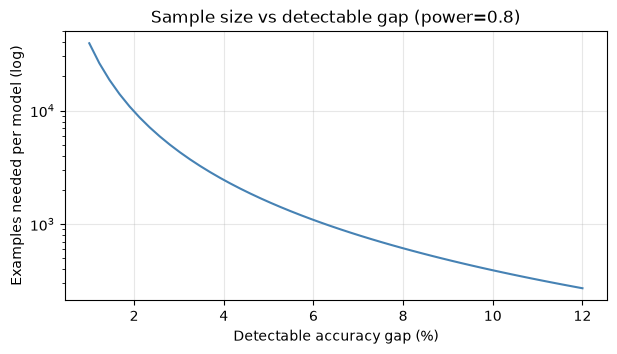

  要检出 10% 差距 → 约需 391 题/模型
  要检出 5% 差距 → 约需 1,567 题/模型
  要检出 2% 差距 → 约需 9,799 题/模型

关键观察：100 题的 benchmark 顶多看出 10% 级别的差距；
  想分辨 2% 的细微差距，得上万题。所以小评测集上的几分之差，多半是噪声。


In [10]:
import matplotlib.pyplot as plt

z_a, z_b = 1.96, 0.84          # α=0.05, power=0.8
p = 0.5                         # 最保守情况
ds = np.linspace(0.01, 0.12, 50)
ns = (z_a + z_b) ** 2 * 2 * p * (1 - p) / ds ** 2

plt.figure(figsize=(7, 3.5))
plt.plot(ds * 100, ns, color="steelblue")
plt.yscale("log")
plt.xlabel("Detectable accuracy gap (%)")
plt.ylabel("Examples needed per model (log)")
plt.title("Sample size vs detectable gap (power=0.8)")
plt.grid(True, alpha=0.3)
plt.show()

for d in [0.10, 0.05, 0.02]:
    n = (z_a + z_b) ** 2 * 2 * p * (1 - p) / d ** 2
    print(f"  要检出 {d*100:.0f}% 差距 → 约需 {int(n):,} 题/模型")

print("\n关键观察：100 题的 benchmark 顶多看出 10% 级别的差距；")
print("  想分辨 2% 的细微差距，得上万题。所以小评测集上的几分之差，多半是噪声。")

### 12.5 读到一张评测表，先问这几个问题

把这一节浓缩成一个检查清单。下次看到论文或排行榜上的模型对比，先问：

- **有没有置信区间 / 误差棒？** 没有的话，单点分数意义有限
- **两个模型测的是不是同一批题？** 是的话应该用配对检验（McNemar），而不是各算各的
- **差距和评测集规模匹配吗？** 100 题上看出的 2% 差距，基本是噪声（12.4）
- **评测标签本身可靠吗？** LLM-as-Judge 或人工标注，要报 κ，不是原始一致率（12.3）

这一节没有训练任何模型，但它回答的是更上游的问题：**在相信一个分数之前，先确认它不是随机波动的产物。** 这是 CMU 把「实验设计」单独列成两讲的原因——跑分容易，判断分数可不可信才是研究的基本功。

## 小结

### 你学会了什么（按章节顺序）

| # | 章节 | 核心内容 |
|:---|:---|:---|
| 1 | 评测全景图 | 2025 论文/工业界在评什么，评测演进路线，新手最小评测集 |
| 2 | 核心 Repo | lm-eval-harness, AlpacaEval, FastChat, DeepEval 选型 |
| 3 | OpenAI-Compatible API | `local-chat-completions` vs `local-completions`，连接任何兼容 API |
| 4 | LLM-as-Judge | MT-Bench prompt + OpenAI SDK 真实打分实现 |
| 5 | 结果汇总与可视化 | 对比表 + 雷达图 + 柱状图 + 胜率矩阵 + 5 种综合评分方法 |
| 6 | AlpacaEval 实战 | 完整 CLI + Python API 流水线，OpenAI-Compatible 集成 |
| 7 | 专项评测 | RAG（RAGAS 忠实度/相关性）、代码（pass@k 与稳定性） |
| 8 | LLM-as-Judge 偏差与一致性 | Position/Length/Egocentric Bias + CR@K/Prompt Robustness |
| 9 | 指标体系 | acc / exact_match / pass@k / win_rate / Elo，2025 新指标（AIME, SWE-bench, LiveCodeBench） |
| 10 | 常见坑 | 数据层（污染/prompt 敏感/few-shot）、工程层（API 混用/seed/temperature）、解读层 |
| 11 | 速查命令 | CLI + Python API，按环境调整后可运行 |

### 推荐 Repo 汇总

```bash
# 核心评测框架
git clone https://github.com/EleutherAI/lm-evaluation-harness.git  # 开源评测常用框架，支持大量任务
git clone https://github.com/tatsu-lab/alpaca_eval.git              # LLM-as-Judge，805 条 prompt
git clone https://github.com/lm-sys/FastChat.git                    # MT-Bench + Chatbot Arena

# 进阶工具
pip install deepeval       # CI/CD 评测（幻觉检测、G-Eval、40+ 指标）
pip install ragas          # RAG 评测（忠实度、相关性）
```

### 下一步建议

```
Level 1（今天就能做）:
  1. pip install lm-eval openai
  2. 用 DeepSeek API 跑通 gsm8k --limit 50
  3. 看懂输出 JSON 里的每个字段

Level 2（这个月）:
  1. vLLM 部署一个开源模型
  2. 跑 4 个核心数据集：gsm8k + mmlu + humaneval + ifeval
  3. 画雷达图 + 算几何平均
  4. 对标公开 leaderboard 验证分数

Level 3（持续做）:
  1. 接入 AlpacaEval / MT-Bench 评测对话质量
  2. 按业务场景自建评测集（RAGAS / 自定义 prompt）
  3. 跟踪一致性指标（CR@K），不只是准确率
```

### 关键概念速查

| 概念 | 一句话解释 |
|:---|:---|
| **loglikelihood vs generate_until** | 选择题算概率（Completions API），生成题自回归（Chat API） |
| **pass@k 与稳定性** | pass@k 乐观（k 次至少 1 次对）；稳定性可用自定义 repeated pass / all-pass@k 统计 |
| **LC Win Rate** | 控制回答长度后的胜率，避免「话多就赢」 |
| **几何平均 vs 算术平均** | 几何平均惩罚短板，模型偏科会立刻暴露 |
| **CR@K** | 同一问题问 K 次，答对的次数比例——衡量稳定性 |
| **Position / Length / Egocentric Bias** | LLM-as-Judge 的三大偏差，需要随机化 + LC + 交叉验证 |
| **数据污染** | 训练集混入评测题导致分数虚高——用 LiveCodeBench 等动态数据集防污染 |

一句话总结：没有评测的模型部署风险很高。评测 = 标准化考题 + 自动化批改 + 可复现的分数 + 持续监控。

## 作业

1. **Perplexity 手算**

   给定一个 3-token 序列，模型输出的 logit 概率（softmax 后）分别是 [0.5, 0.3, 0.2]、[0.1, 0.7, 0.2]、[0.4, 0.1, 0.5]，手动计算 perplexity。

   <details><summary>小提示</summary>对每个 token 取 log 概率，求平均，再取 exp。Perplexity 越低说明模型越「自信」。</details>

2. **LLM-as-Judge 偏差检测**

   设计一个实验：对同一对回答交换位置（answer_a 和 answer_b 对调），重复 3 次，统计 GPT-4 给分的差异。用代码计算 Position Bias 率。

   <details><summary>小提示</summary>Position Bias 率 = 交换前后评分不一致的次数 / 总次数。不一致说明裁判被位置影响了。</details>

3. **评测报告撰写**

   用下面的模拟数据画一张雷达图，计算两个模型在 4 个 benchmark 上的几何平均分，写出结论。

   ```python
   scores = {
       'Model A': {'gsm8k': 82, 'mmlu': 71, 'humaneval': 65, 'ifeval': 78},
       'Model B': {'gsm8k': 78, 'mmlu': 75, 'humaneval': 70, 'ifeval': 72},
   }
   ```

   <details><summary>小提示</summary>几何平均 = (a * b * c * d) ** (1/4)。对比两个模型的几何平均，同时观察雷达图上哪个模型更「均衡」。</details>


In [ ]:
# 作业 1：手算 Perplexity（填空）
import math

# 三个 token 位置的 softmax 概率分布
probs = [[0.5, 0.3, 0.2], [0.1, 0.7, 0.2], [0.4, 0.1, 0.5]]
# 教学上把每行最大概率当作"模型预测该位置正确 token 的概率"
# 小提示：per_token_prob = 每行的最大值；avg_log_prob = mean(log(per_token_prob))
per_token_prob = None  # 例如 [0.5, 0.7, 0.5]
avg_log_prob = None    # 平均 log 概率
perplexity = None      # exp(-avg_log_prob)

assert per_token_prob is not None, "请先算 per_token_prob"
assert avg_log_prob is not None, "请先算 avg_log_prob"
assert perplexity is not None, "请先算 perplexity"

expected_probs = [max(p) for p in probs]                       # [0.5, 0.7, 0.5]
assert per_token_prob == expected_probs, "per_token_prob 应为每行的最大值"
expected_avg = sum(math.log(p) for p in expected_probs) / len(expected_probs)
assert abs(avg_log_prob - expected_avg) < 1e-6, "avg_log_prob 算错了"
expected_ppl = math.exp(-expected_avg)
assert abs(perplexity - expected_ppl) < 1e-4, "perplexity 算错了"

print(f"每个 token 概率: {per_token_prob}")
print(f"平均 log 概率: {avg_log_prob:.4f}")
print(f"Perplexity: {perplexity:.3f}")
print("✅ 作业 1 通过：Perplexity = exp(-平均 log 概率)，越低说明模型越自信。")

In [ ]:
# 作业 2：Position Bias 检测（填空）
# 对同一对回答做 3 次交换实验：answer_a 在前 vs 交换到 answer_b 在前。
# 如果两次评分的高低关系变了，说明裁判被位置影响。
# 小提示：Position Bias 率 = 不一致次数 / 总实验次数

# scores_before / scores_after 都是 [answer_a 得分, answer_b 得分]，得分高者胜
experiments = [
    ([8.0, 6.0], [7.5, 6.5]),   # 前后都 a 胜 → 一致
    ([7.0, 9.0], [9.5, 7.0]),   # 前 b 胜，后 a 胜 → 不一致
    ([6.0, 5.0], [5.5, 5.0]),   # 前后都 a 胜 → 一致
]

def winner(scores):
    # 返回 0 表示 answer_a 胜，1 表示 answer_b 胜
    return 0 if scores[0] >= scores[1] else 1

# TODO: 统计"不一致"的次数（列表推导或循环）
inconsistent = None

assert inconsistent is not None, "请先统计不一致次数"
total = len(experiments)
expected = sum(1 for before, after in experiments if winner(before) != winner(after))
assert inconsistent == expected, f"不一致次数应为 {expected}"

position_bias_rate = inconsistent / total
assert 0 <= position_bias_rate <= 1, "Position Bias 率应在 0 到 1 之间"

print(f"实验总数: {total}，不一致次数: {inconsistent}")
print(f"Position Bias 率: {position_bias_rate:.0%}")
if position_bias_rate > 0:
    print("说明：这份数据里裁判被位置影响了。")
else:
    print("说明：这份数据里没观察到位置偏差。")
print("✅ 作业 2 通过：Position Bias 率越高，裁判越容易被位置影响。")

In [ ]:
# 作业 3：几何平均分（填空）
import math

scores = {
    'Model A': {'gsm8k': 82, 'mmlu': 71, 'humaneval': 65, 'ifeval': 78},
    'Model B': {'gsm8k': 78, 'mmlu': 75, 'humaneval': 70, 'ifeval': 72},
}

# TODO: 计算两个模型的几何平均分
# 小提示：几何平均 = (a * b * c * d) ** (1/4)，可以用 math.prod
geo_mean = {}  # 例如 {'Model A': ..., 'Model B': ...}

assert geo_mean is not None, "请先计算 geo_mean"
assert len(geo_mean) == 2, "应包含两个模型的几何平均"

for name, m in scores.items():
    vals = list(m.values())
    expected = (math.prod(vals)) ** (1 / len(vals))
    assert abs(geo_mean[name] - expected) < 1e-6, f"{name} 的几何平均算错了"

print(f"几何平均分: {geo_mean}")
print(f"Model A 更高: {geo_mean['Model A'] > geo_mean['Model B']}")
print("几何平均会惩罚偏科：Model B 各项更稳，Model A 在 humaneval 上明显偏弱。")
print("✅ 作业 3 通过：几何平均能反映模型在多个评测上的均衡性。")

## 13. 综合实战：用 lm-eval 正式评测我们训练的模型

第 2 站里，9.34M 紧凑模型的 loss 确实下降了，也能输出一些文字。可「能输出」不等于
「会做题」：一句回答看起来顺畅，可能只是碰巧；一句回答很混乱，也不能说明所有任务都失败。
怎样把这种主观印象换成可以重复、可以比较的证据？

这一站沿用前两站的真实训练记录，完成四件事：

1. **框架上手**：用 lm-eval 和真实 Hugging Face 小模型跑通 HellaSwag
2. **正式评测**：读取 64M 教学模型的六组完整 GSM8K 结果
3. **质量诊断**：用重复 n-gram 和最长重复片段量化复读循环
4. **诚实归因**：区分评测口径、统计波动和当前规模下的模型容量限制

> 🔬 **From-0 实战线 3/3**：第 1 站训练 Tokenizer，第 2 站完成 PT/SFT，
> 这一站检验模型究竟学会了什么。

### 13.1 先把评测框架跑通

**lm-eval（EleutherAI lm-evaluation-harness）**：一个用统一接口加载模型、组织 benchmark、
计算指标并保存配置的开源评测框架。通俗地说，它像一套统一的试卷和阅卷规则：GSM8K、
MMLU、HellaSwag 等任务都能按记录清楚的口径运行，因此常被开源社区用来报告可复现结果。

先用 `hf-internal-testing/tiny-random-LlamaForCausalLM` 跑 HellaSwag。这个模型只有随机权重，
选择它不是为了取得高分，而是为了用很少的计算验证「模型加载 → 任务读取 → 计算指标」全链路。

**HellaSwag**：给一段场景和四个候选结尾，让模型选出最合理的结尾。下面固定 0-shot、随机
种子 42，并取验证集的 1%。`limit` 适合验证流程，不适合发布正式成绩。

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The following generation flags are not valid and may be ignored: ['pad_token_id']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/21 [00:00<?, ?it/s]

Loading weights:   5%|▍         | 1/21 [00:00<00:02,  7.88it/s]

Loading weights: 100%|██████████| 21/21 [00:00<00:00, 143.09it/s]

...

Running loglikelihood requests:   0%|          | 1/404 [00:03<26:18,  3.92s/it]

Running loglikelihood requests:  38%|███▊      | 153/404 [00:04<00:04, 53.69it/s]

Running loglikelihood requests:  74%|███████▎  | 297/404 [00:04<00:00, 119.97it/s]

Running loglikelihood requests: 100%|██████████| 404/404 [00:04<00:00, 96.42it/s] 

真实运行样本数：101
acc：25.74%
acc_norm：34.65%
关键观察：随机小模型接近四选一基线；这一步验证的是评测链路，不是模型能力。


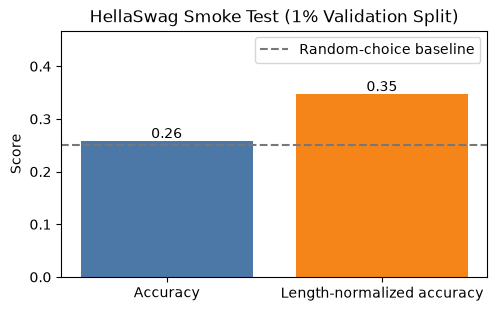

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from lm_eval import simple_evaluate


smoke_result = simple_evaluate(
    model="hf",
    model_args={
        "pretrained": "hf-internal-testing/tiny-random-LlamaForCausalLM",
        "dtype": "float32",
    },
    tasks=["hellaswag"],
    num_fewshot=0,
    batch_size=4,
    device="cuda:0",
    limit=0.01,
    bootstrap_iters=0,
    log_samples=False,
    verbosity="ERROR",
    random_seed=42,
    numpy_random_seed=42,
    torch_random_seed=42,
    fewshot_random_seed=42,
)

hellaswag = smoke_result["results"]["hellaswag"]
effective_samples = smoke_result["n-samples"]["hellaswag"]["effective"]
smoke_scores = [hellaswag["acc,none"], hellaswag["acc_norm,none"]]

print(f"真实运行样本数：{effective_samples}")
print(f"acc：{smoke_scores[0]:.2%}")
print(f"acc_norm：{smoke_scores[1]:.2%}")
print("关键观察：随机小模型接近四选一基线；这一步验证的是评测链路，不是模型能力。")

fig, ax = plt.subplots(figsize=(5.5, 3.2))
bars = ax.bar(["Accuracy", "Length-normalized accuracy"], smoke_scores,
              color=["#4C78A8", "#F58518"])
ax.axhline(0.25, color="#777777", linestyle="--", label="Random-choice baseline")
ax.bar_label(bars, fmt="%.2f")
ax.set_ylim(0, max(smoke_scores + [0.25]) * 1.35)
ax.set_ylabel("Score")
ax.set_title("HellaSwag Smoke Test (1% Validation Split)")
ax.legend()
plt.show()

`acc` 直接统计选对比例；`acc_norm` 先按候选答案长度归一化 log-likelihood，再选择得分最高的
答案。随机权重的四选一基线约为 25%，少量样本还会带来明显波动，所以这里不比较模型强弱。

同一段实验也可以写成命令行：

```bash
lm_eval --model hf \
  --model_args pretrained=hf-internal-testing/tiny-random-LlamaForCausalLM,dtype=float32 \
  --tasks hellaswag --num_fewshot 0 --batch_size 4 --limit 0.01 --seed 42
```

看到两个来自 lm-eval 的分数后，为什么还不能随意找排行榜数字比较？因为结果由三件事共同定义：

| 必须记录的项目 | 本次设置 | 改变后会怎样 |
|:---|:---|:---|
| 任务名与版本 | `hellaswag`，lm-eval 0.4.12 | prompt、数据处理或答案解析可能改变 |
| 指标口径 | `acc` / `acc_norm` | 是否做长度归一化会影响选项排序 |
| few-shot 数 | 0-shot | 示例数量与示例抽样会改变上下文 |

只有任务、版本、指标、few-shot、prompt 模板和样本范围都对齐，两个结果才真正可比。

### 13.2 正式评测 64M 教学模型：GSM8K

**GSM8K**：由 1,319 道小学数学文字题组成的测试集，模型要生成推理过程和最终数值答案。
通俗地说，它不只问「下一词像不像」，而是检查模型能否读懂条件、完成多步计算并给出答案。

**exact_match,strict-match**：按任务规定的严格答案格式提取结果，再判断预测与标准答案是否
完全相同。通俗地说，计算过程写得像并不计分，最终答案必须被规则正确提取且数值相同。

第 2 站的 9.34M 模型在 Notebook 内存中完成训练，没有保存 SFT checkpoint；这里不假装重新
评测它。我们改用仓库里六次 64M 教学模型的完整 lm-eval 结果。每次都评测全部 1,319 题，
不是 `limit` 子集。模型是仓库自定义结构，正式运行时通过适配器接入 lm-eval 的 `gsm8k` 任务；
下面直接读取运行后保存的原始 JSON，并重新计算表格、置信区间和图。

读取文件数：6
每组题数：1319
每组答对：8
strict exact match：0.61%
95% Wilson CI：[0.31%, 1.19%]
关键观察：六种数据与 SFT 设置都得到相同分数，单次改配方没有跨过当前能力门槛。


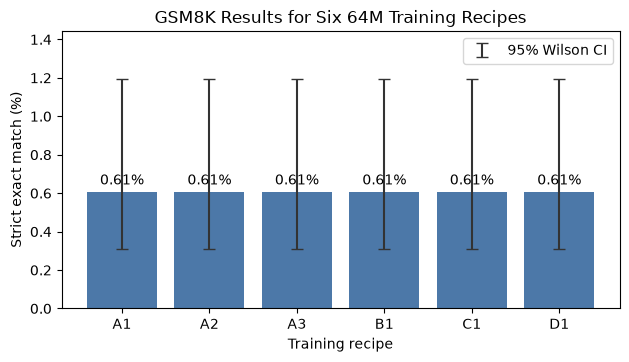

In [2]:
report_dir = Path("llm_train/reports")
result_files = sorted(report_dir.glob("eval_gsm8k_*.json"))
assert len(result_files) == 6, "应当找到六组 GSM8K 结果"

short_names = ["A1", "A2", "A3", "B1", "C1", "D1"]
strict_scores = []
sample_counts = []
correct_counts = []

for result_path in result_files:
    with result_path.open(encoding="utf-8") as file:
        task_result = json.load(file)["tasks"]["gsm8k"]
    score = task_result["exact_match,strict-match"]
    count = task_result["sample_len"]
    strict_scores.append(score)
    sample_counts.append(count)
    correct_counts.append(round(score * count))

assert sample_counts == [1319] * 6, "六组实验都应覆盖完整测试集"
assert max(strict_scores) == min(strict_scores), "本次记录的六组分数应当相同"

# Wilson 区间比 p ± 1.96*SE 更适合接近 0 的准确率。
z = 1.96
intervals = []
for correct, count in zip(correct_counts, sample_counts):
    proportion = correct / count
    denominator = 1 + z ** 2 / count
    center = (proportion + z ** 2 / (2 * count)) / denominator
    margin = z * (proportion * (1 - proportion) / count
                  + z ** 2 / (4 * count ** 2)) ** 0.5 / denominator
    intervals.append((center - margin, center + margin))

print(f"读取文件数：{len(result_files)}")
print(f"每组题数：{sample_counts[0]}")
print(f"每组答对：{correct_counts[0]}")
print(f"strict exact match：{strict_scores[0]:.2%}")
print(f"95% Wilson CI：[{intervals[0][0]:.2%}, {intervals[0][1]:.2%}]")
print("关键观察：六种数据与 SFT 设置都得到相同分数，单次改配方没有跨过当前能力门槛。")

score_percent = [score * 100 for score in strict_scores]
lower_error = [(score - low) * 100 for score, (low, high) in zip(strict_scores, intervals)]
upper_error = [(high - score) * 100 for score, (low, high) in zip(strict_scores, intervals)]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
bars = ax.bar(short_names, score_percent, color="#4C78A8")
ax.errorbar(short_names, score_percent, yerr=[lower_error, upper_error], fmt="none",
            ecolor="#333333", capsize=4, label="95% Wilson CI")
ax.bar_label(bars, labels=[f"{score:.2f}%" for score in score_percent], padding=3)
ax.set_ylim(0, max(upper_error) + score_percent[0] + 0.25)
ax.set_xlabel("Training recipe")
ax.set_ylabel("Strict exact match (%)")
ax.set_title("GSM8K Results for Six 64M Training Recipes")
ax.legend()
plt.show()

六组 JSON 的真实结果如下。0.61% 对应 1,319 题中答对 8 题：

| 实验 | 数据 / SFT 策略 | 题数 | 答对 | exact_match,strict-match |
|:---|:---|---:|---:|---:|
| A1 | 数学 scratchpad v2 | 1,319 | 8 | 0.61% |
| A2 | Belle + 数学 scratchpad v2 | 1,319 | 8 | 0.61% |
| A3 | Belle + 更长的 CoT | 1,319 | 8 | 0.61% |
| B1 | 仅 Belle | 1,319 | 8 | 0.61% |
| C1 | Belle，block size 1024 | 1,319 | 8 | 0.61% |
| D1 | 10B-token PT + Belle | 1,319 | 8 | 0.61% |

这不是「评测没有意义」，而是评测把一个重要事实显示出来了：数据组合、CoT 长度、上下文长度
和训练 token 数发生变化后，六次结果仍停在同一点。在当前架构、数据和训练流程的共同约束下，
64M 模型遇到了容量门槛；只调整 SFT 配方没有让多步数学能力出现可测提升。这与
[Scaling Laws 一章](../part2-training/12-scaling-laws.ipynb)的直觉一致：数据、计算量与参数规模
需要配合增长，单独增加某一项并不保证下游能力随之出现。

还要保留一个统计上的限定：本章第 12.4 节说明，想检出越小的差距，需要的题目越多。
8/1,319 的 95% Wilson 区间约为 0.31%～1.19%。六组预测可能答对相同数量，却不是相同题目；
没有逐题记录就不能做本章第 12.2 节的 McNemar 配对检验。因此，
我们能说「没有测出配方差异」，不能证明六个模型在所有输入上都完全相同。

如果你有同结构 checkpoint，可以沿用同一口径重新运行。下面的命令展示记录这些 JSON 时的
关键参数；自定义模型适配逻辑在仓库评测模块中，Notebook 的分析代码不依赖训练时的内存状态。

```bash
HIP_VISIBLE_DEVICES=0 CUDA_VISIBLE_DEVICES=0 \
python llm_train/scripts/run_eval.py \
  --ckpt llm_train/checkpoints/gsm8k_a1_scratchpad_v2/sft.pt \
  --model_type dense --tasks gsm8k \
  --out llm_train/reports/eval_gsm8k_a1_scratchpad_v2.json
```

发布结果时至少同时写明：checkpoint、任务名、lm-eval 版本、few-shot 数、prompt/chat template、
样本数和指标键。只写「GSM8K 0.61%」会丢失复现所需的关键信息。

### 13.3 单点分数之外：量化复读循环

GSM8K 的 exact match 能判断答案是否正确，却不会告诉我们模型为什么失败。模型可能算错一步，
也可能输出毫无关联的句子，或者陷入短语循环。这些失败需要生成质量指标补充。

**重复 n-gram 比例**：把文本切成连续的 $n$ 个单位，统计第二次及以后出现的窗口占全部窗口的
比例。通俗地说，同一个短片段反复出现得越多，这个比例越高。

**最长重复片段**：文本中至少出现两次且互不重叠的最长连续单位序列。通俗地说，它直接指出
模型循环了哪一段。下面把一个汉字、一个英文单词、一个数字或一个标点看作一个单位，并使用
trigram（$n=3$）检测。它不是通用语义指标，只负责发现局部循环。

In [3]:
def repetition_diagnostics(text, n=3):
    """计算重复 n-gram 比例和最长的非重叠重复片段。

    参数：
        text: 要诊断的生成文本。
        n: n-gram 中连续单位的数量。
    返回：
        包含重复比例、最长片段及其长度的字典。
    """
    units = re.findall(r"[\u4e00-\u9fff]|[A-Za-z]+|\d+|[^\s]", text)
    ngrams = [tuple(units[i:i + n]) for i in range(len(units) - n + 1)]
    counts = Counter(ngrams)
    repeated = sum(count - 1 for count in counts.values() if count > 1)
    ratio = repeated / len(ngrams) if ngrams else 0.0

    longest = ()
    for length in range(1, len(units) // 2 + 1):
        first_position = {}
        found = ()
        for start in range(len(units) - length + 1):
            fragment = tuple(units[start:start + length])
            if fragment in first_position and start - first_position[fragment] >= length:
                found = fragment
                break
            first_position.setdefault(fragment, start)
        if not found:
            break
        longest = found

    return {
        "repeat_ngram_ratio": ratio,
        "longest_fragment": "".join(longest),
        "longest_fragment_units": len(longest),
    }

9.34M / 150-step SFT
  重复 trigram 比例：0.00%
  最长重复片段：'，'
  片段长度：1 个单位
64M repetition failure
  重复 trigram 比例：25.00%
  最长重复片段：'这颗金银财宝'
  片段长度：6 个单位


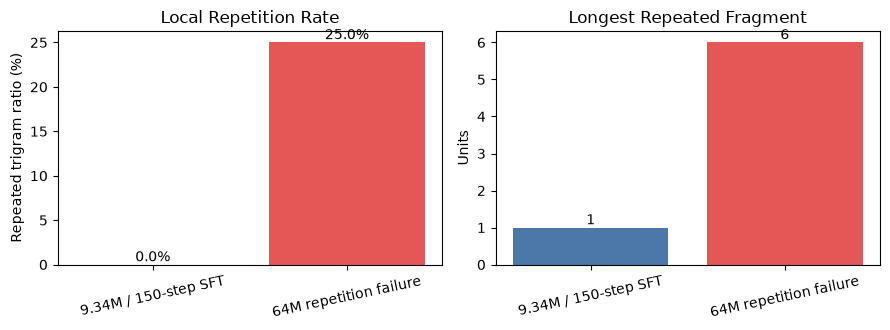

关键观察：64M 失败样例有清楚的短语循环；紧凑模型不复读也不代表语义正确。


In [4]:
generation_samples = {
    "9.34M / 150-step SFT": (
        "可一色生激靟故事，并写个法》，程影式同的"
    ),
    "64M repetition failure": (
        "里面充满了金银财宝，有金银财宝在身边，还有一粒金银财宝。"
        "他决定去寻找这颗金银财宝，找到这颗金银财宝。"
    ),
}

diagnostics = {
    name: repetition_diagnostics(text, n=3)
    for name, text in generation_samples.items()
}

for name, result in diagnostics.items():
    print(name)
    print(f"  重复 trigram 比例：{result['repeat_ngram_ratio']:.2%}")
    print(f"  最长重复片段：{result['longest_fragment']!r}")
    print(f"  片段长度：{result['longest_fragment_units']} 个单位")

names = list(diagnostics)
ratios = [diagnostics[name]["repeat_ngram_ratio"] * 100 for name in names]
lengths = [diagnostics[name]["longest_fragment_units"] for name in names]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
ratio_bars = axes[0].bar(names, ratios, color=["#4C78A8", "#E45756"])
axes[0].bar_label(ratio_bars, fmt="%.1f%%")
axes[0].set_ylabel("Repeated trigram ratio (%)")
axes[0].set_title("Local Repetition Rate")
axes[0].tick_params(axis="x", rotation=12)

length_bars = axes[1].bar(names, lengths, color=["#4C78A8", "#E45756"])
axes[1].bar_label(length_bars)
axes[1].set_ylabel("Units")
axes[1].set_title("Longest Repeated Fragment")
axes[1].tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()

print("关键观察：64M 失败样例有清楚的短语循环；紧凑模型不复读也不代表语义正确。")

这组诊断揭示了 exact match 看不到的差异：64M 失败样例反复生成「金银财宝」，重复 trigram
比例和最长重复片段都明显更高；9.34M 的短回答没有形成相同循环，但语义依然混乱。

所以「重复率低」不是「回答优质」的同义词。正式评测应同时保留三层证据：

1. benchmark 分数回答「任务做对了多少」
2. 统计区间回答「这个数字有多不确定」
3. 失败样例与生成诊断回答「模型以什么方式失败」

### 13.4 从这个实战学到的三件事

1. **小模型触及能力门槛是正常实验结果。** 64M 模型能学习语言模式，不代表多步数学能力会
   自动出现。六组 0.61% 没有证明训练白费，而是告诉我们下一轮应重新考虑模型规模、数据质量
   与计算量的配比，而不是继续只改 SFT 配方。
2. **评测口径决定结论能否比较。** 同一个任务名下面，few-shot、prompt、答案提取规则、chat
   template 和样本范围都可能改变分数。完整配置与指标键必须和数字一起保存。
3. **失败样例和成功样例同样有价值。** exact match 定位能力缺口，重复检测进一步区分「计算错」
   与「生成循环」。只有看到具体失败方式，下一次训练改动才有明确目标。

### 实战小结（checklist）

确认你已经能解释下面这些问题：

1. ✅ lm-eval 用统一任务接口和指标口径，让不同模型的结果可以复现
2. ✅ `limit=0.01` 适合验证链路，正式成绩应覆盖完整测试集
3. ✅ 比较结果前要对齐任务版本、指标、few-shot、prompt 与样本范围
4. ✅ 六组 64M 教学模型都在 GSM8K 得到 8/1,319，即 strict exact match 0.61%
5. ✅ 置信区间较宽时，应说「没有测出差异」，不能说「能力完全相同」
6. ✅ 重复 n-gram 能发现循环，但不能替代正确性和语义质量评测
7. ✅ 评测报告既要保留总分，也要保留成功样例、失败样例和运行配置

> 🔬 **From-0 实战线 3/3 完成**
>
> [02 BPE Tokenizer](../part1-foundation/02-bpe-tokenizer.ipynb)
> → [11 PT / SFT](../part2-training/11-training-loss.ipynb)
> → **28 正式评测**
>
> 你已经走完「训练 Tokenizer → 预训练 → SFT → 正式评测」的完整闭环。